# Testing Menura on MHD modes

Commit d2ef46a9

Using initial sinusoidal low amplitude perturbations of the magnetic field, we verify the dispersion relations of the Alfven and fast magnetosonic modes resulting from the solver.

$B_1(z) = 0.05\cdot sin(k\cdot x) \cdot B_0$

with $B_0$ either along the $x$-axis (i.e. Alfven mode) or across it (magnetosonic). We use a 2D spatial domain squeezed along the y-axis (at least 6 nodes and their guard-nodes, to avoid a signal periodic over 2 dx) to make the simulation lighter without implementing a 1-dimensional version of the code.

In [2]:
from menura_utils import *
import own_tools as oT
import own_colours as oC
path = '../menura'

## Alfven mode

In a first part, we set the background magnetic field *along* the *x*-axis, initialising six modes described above.

In [8]:
mp = menura_param(f'{path}')
mp.print_physical_parameters()

dens_t_s = np.load(f'{path}/products/dens_time_space_rank0.npy')
E_t_s = np.load(f'{path}/products/E_time_space_rank0.npy')
B_t_s = np.load(f'{path}/products/B_time_space_rank0.npy')


._____________________________________________________________________________________
| Physical run parameters:
|    
| 1 process.
|
| Dimensionality:                  2D 
|
| B_0:                              1.80e-09 T
| n_0:                              1.00e+06 m^-3
| T_eon:                            1.00e+05 K
| T_ion:                            1.00e+04 K
|
| Proton plasma frequency:         1316.5700 rad/s
| Proton gyrofrequency:               0.1724 rad/s
| Electron plasma frequency:       5.6422e+04 rad/s
| Electron gyrofrequency:           316.5660 rad/s
|
| Proton inertial length d_i :      227.7080 km
| Electron inertial length d_e :      5.3134 km
| Debye length lambda_D :             0.0218 km
| Gyro-radius (v_th) :                0.3273
|
| Alfven speed :                     39.2516 km/s
| Sound speed :                      32.7535 km/s
| Magnetosonic speed :               51.1222 km/s
| Ion thermal speed :                12.8470 km/s
| Electron thermal speed :      

In [11]:
from scipy.signal import blackman, hamming
def field_omega_k_spectrum2(field_t_s, field_label, dt, dx, lp, loglog=True,
                           disp_rel='', savefig=False):

    len_t = int(field_t_s.shape[0])
    len_x = int(field_t_s.shape[1])
    grid_t = np.arange(len_t)*dt
    grid_x = np.arange(len_x)*dx

    if field_t_s.ndim==3:
        field_t_s = np.mean(field_t_s[:, :, 2:-2], axis=2)#-np.mean(field_t_s)
    
    
    field_t_s *= blackman(len_t)[:, None]
    #
    PSD = np.fft.fftshift(fft2(field_t_s))
    PSD = np.abs(PSD) #2./xLen *
    #
    f_t = np.fft.fftshift(np.fft.fftfreq(len_t, d=dt))
    f_x = np.fft.fftshift(np.fft.fftfreq(len_x, d=dx))
    #
    k_vec = f_x*2.*np.pi
    omega = f_t*2.*np.pi
    #
    half_len_x = int(len_x/2.)
    half_len_t = int(len_t/2.)
    #
    grid_k = k_vec[half_len_x:]
    grid_omega = omega[half_len_t:]
    dk = grid_k[1]-grid_k[0]
    domega = grid_omega[1]-grid_omega[0]
    edges_k = np.append(grid_k-dk/2, grid_k[-1]+dk/2)
    edges_omega = np.append(grid_omega-domega/2, grid_omega[-1]+domega/2)
    if edges_k[0]<0:
        edges_k[0] = .5*edges_k[1]
    if edges_omega[0]<0:
        edges_omega[0] = .5*edges_omega[1]

    a0 = (PSD)[half_len_t:,half_len_x:]


    fig, AX = plt.subplots(1,2, figsize=(18,14))

    m0 = AX[0].pcolormesh(grid_x, grid_t, field_t_s,#grid_x/lambda_osc, grid_t/T_osc, field,
                          # vmin = .85, vmax = 1.15,
                           cmap=oC.bwr_2, rasterized=True)
    AX[0].set_xlabel('$x/d_{i0}$', fontsize=20)# / lambda_oscillation')
    AX[0].set_ylabel('$t.\omega_{ci0}$', fontsize=20)# / T_oscillation')
    AX[0].set_title(field_label, fontsize=20)


    AX[1].pcolormesh(edges_k, edges_omega, (a0),
                     vmin = 0, vmax = np.amax(a0)*.5,
                     cmap=oC.wbr_1, rasterized=True)

    #AX[1].plot(grid_k, v_s*grid_k, 'k', label=f'Ion acoustic\n(gamma i = 3, gamma e = {gamma_e})')
    ## AX[1].plot(k_iaw, omega_iaw_1)

    if disp_rel == 'alfven':
        sol1 = np.load('/home/etienneb/Models/Leo/analysis/solution_1.npy', allow_pickle=True).item()
        sol2 = np.load('/home/etienneb/Models/Leo/analysis/solution_2.npy', allow_pickle=True).item()
        AX[1].plot(sol1['k'], sol1['omega'], oC.rgb[0], label='WHAMP solutions')
        AX[1].plot(sol2['k'], sol2['omega'], oC.rgb[0])
        AX[1].scatter([1.84], [3.89], s=600, facecolor='none', edgecolor='k')
        AX[1].scatter([0.61], [0.82], s=600, facecolor='none', edgecolor='k')
        AX[1].scatter([0.61], [0.44], s=600, facecolor='none', edgecolor='k')
        # AX[1].plot(grid_k, grid_k, '--k', label='MHD Alfven (omega=k)')
        # grid_om = grid_omega*lp.omega_ci
        # k_alf = np.sqrt( 1/lp.c**2 * (grid_om**2 - lp.omega_i**2/(1-lp.omega_ci**2/grid_om**2)) )
        # k_alf *= lp.d_i
        # AX[1].plot(grid_k, grid_k*np.sqrt(1+(1.4*grid_k)**2*(lp.v_s/lp.v_A)**2), '--', c=oC.rgb[0])
        # AX[1].plot(k_alf, grid_omega, c=oC.rgb[2], label='Alfven')
    elif disp_rel == 'magnetosonic':
        AX[1].plot(grid_k, lp.v_ms/lp.v_A*grid_k, c=oC.rgb[0], label='$\omega/k=v_{magnetosonic}$', lw=1)
    elif disp_rel == 'magnetosonic2':
            v_s      = np.sqrt(lp.k_B*(5./3.*lp.Te_inf+3*lp.Ti_inf)/lp.m_i)
            v_ms_iso = np.sqrt(lp.c**2*(lp.v_A**2+v_s**2)/(lp.v_A**2+lp.c**2))
            AX[1].plot(grid_k, lp.v_ms/lp.v_A*grid_k, c=oC.rgb[0], label='$\omega/k=v_{magnetosonic} isothermal$', lw=1)
            AX[1].plot(grid_k, v_ms_iso/lp.v_A*grid_k, '--', c=oC.rgb[0], label='polytropic 5/3', lw=1)
    elif disp_rel == 'two_stream':
        AX[1].scatter([0.738156], [.81127], s=40, facecolor=oC.rgb[1], edgecolor='w')
    elif disp_rel == 'acoustic':
        AX[1].plot(grid_k, lp.v_s/lp.v_A*grid_k, c=oC.rgb[0], label='$\omega/k=v_{sound}$')
        AX[1].scatter([2.454], [5.108], s=40, facecolor=oC.rgb[1], edgecolor='w', label='WHAMP')
    # AX[1].set_xlim([1e-3, 6])
    # AX[1].set_ylim([1e-3, 20])
    # AX[1].set_xlim([edges_k[0], edges_k[-1]])
    # AX[1].set_ylim([edges_omega[0], edges_omega[-1]])

    AX[1].set_xlabel('$k.d_{i0}$', fontsize=20)
    AX[1].set_ylabel('$\omega/\omega_{ci0}$', fontsize=20)
    if loglog:
        AX[1].set_xscale('log')
        AX[1].set_yscale('log')

    AX[1].legend(loc=2, fontsize=20)

    oT.set_spines(AX)
    plt.tight_layout()
    if savefig:
        plt.savefig('saved_fig.pdf')
    plt.show()

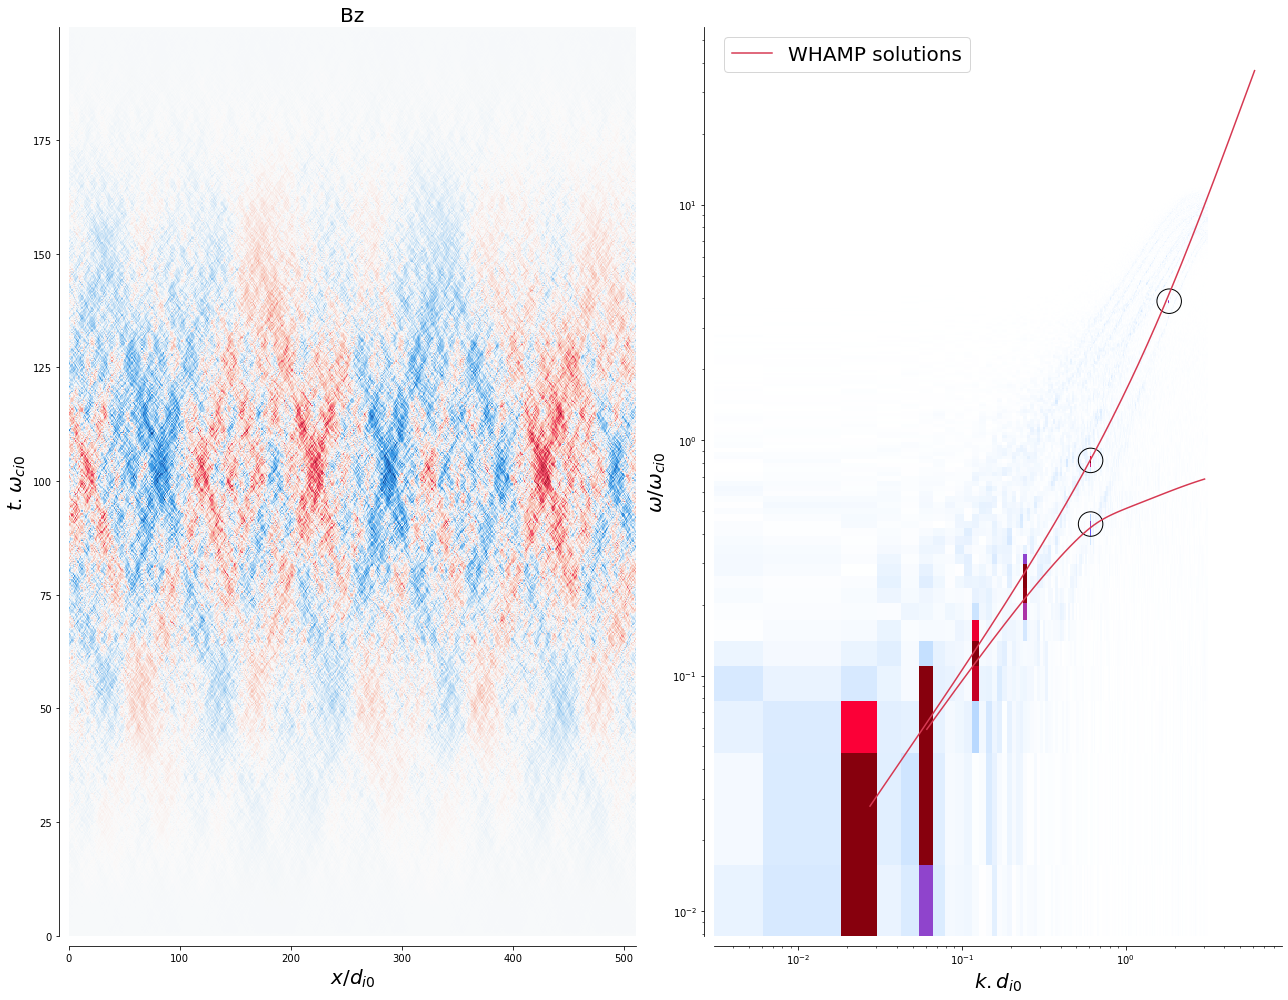

In [12]:
field_omega_k_spectrum2(B_t_s[2]-np.mean(B_t_s[2]), 'Bz', mp.dt_low, mp.dx_low, mp, loglog=True, disp_rel='alfven', savefig=True)
#field_omega_k_spectrum2(E_t_s[1]-np.mean(E_t_s[1]), 'Ey', mp.dt_low, mp.dx_low, mp, loglog=True, disp_rel='alfven')

We have used here 6 modes, the last one can be spotted for $k.d_{i0}$~2. The low spatial frequency modes fall perfectly on the fluid Alfven dispersion relation ($\omega=k$, as velocities are normalised to the Alfven velocity in the code), whereas a departure from the linear MHD relation is found for higher spatial frequencies, when $\omega$ approaches $\omega_{ci}$: the modes then split to the whistler branch and the .

## Magnetosonic mode

We then set the background magnetic field along the *z*-axis, across the preferential direction of the simulation domain (*x*-axis).

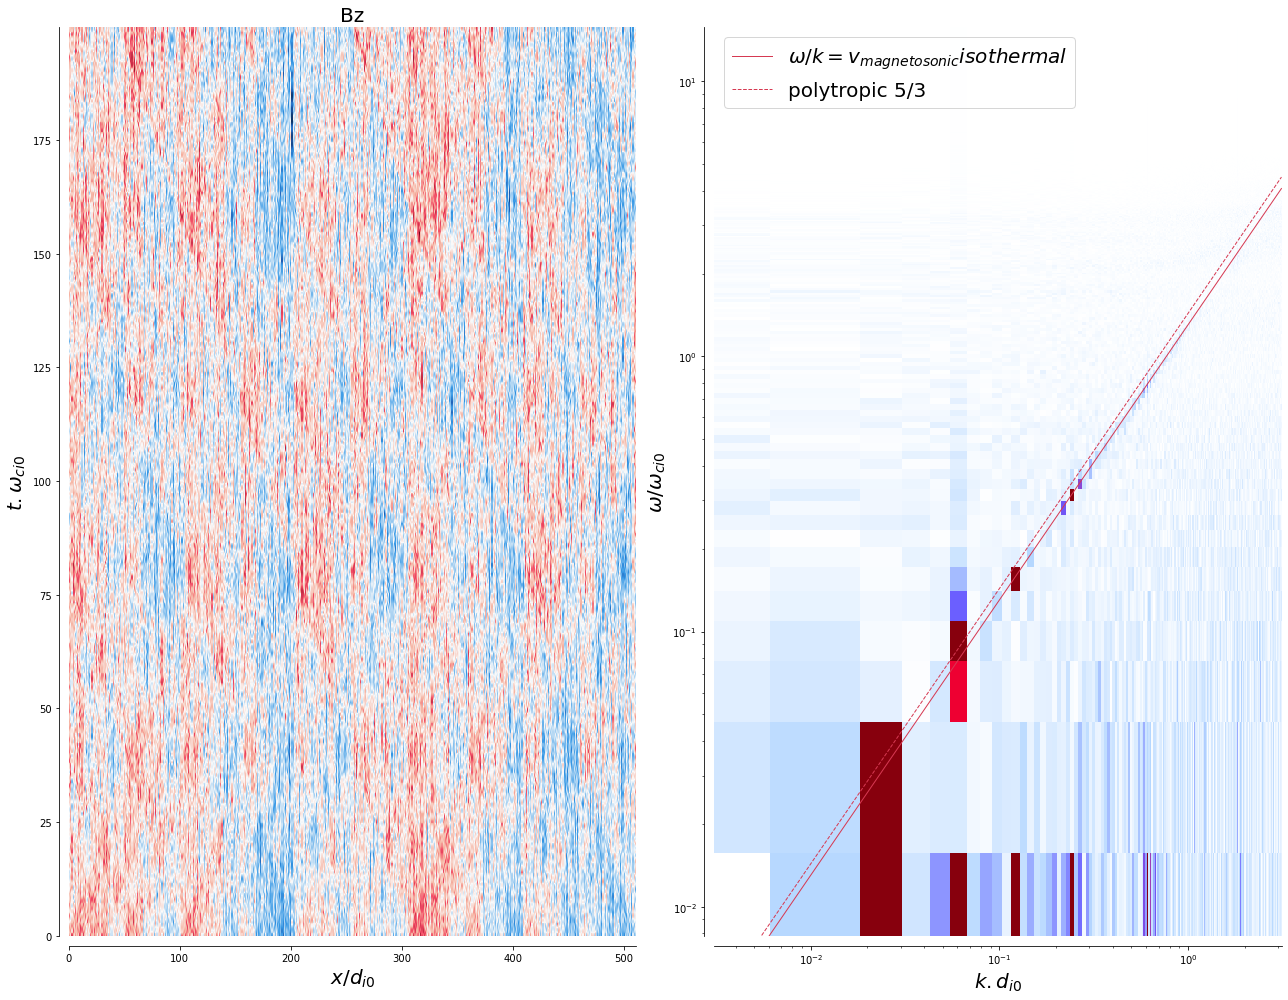

In [2]:
mp = menura_param(f'{path}')

#dens_t_s = np.load(f'{path}/products/dens_time_space.npy')
#E_t_s = np.load(f'{path}/products/E_time_space.npy')
B_t_s = np.load(f'{path}/products/B_time_space_rank0.npy')

#field_omega_k_spectrum(dens_t_s-np.mean(dens_t_s), 'Density', lp.dt_low, lp.dx_low, lp, disp_rel='magnetosonic')
#field_omega_k_spectrum(E_t_s[1]-np.mean(E_t_s[1]), 'Ey', lp.dt_low, lp.dx_low, lp, disp_rel='magnetosonic')
field_omega_k_spectrum(B_t_s[2]-np.mean(B_t_s[2]), 'Bz', mp.dt_low, mp.dx_low, mp, disp_rel='magnetosonic2', savefig=True)

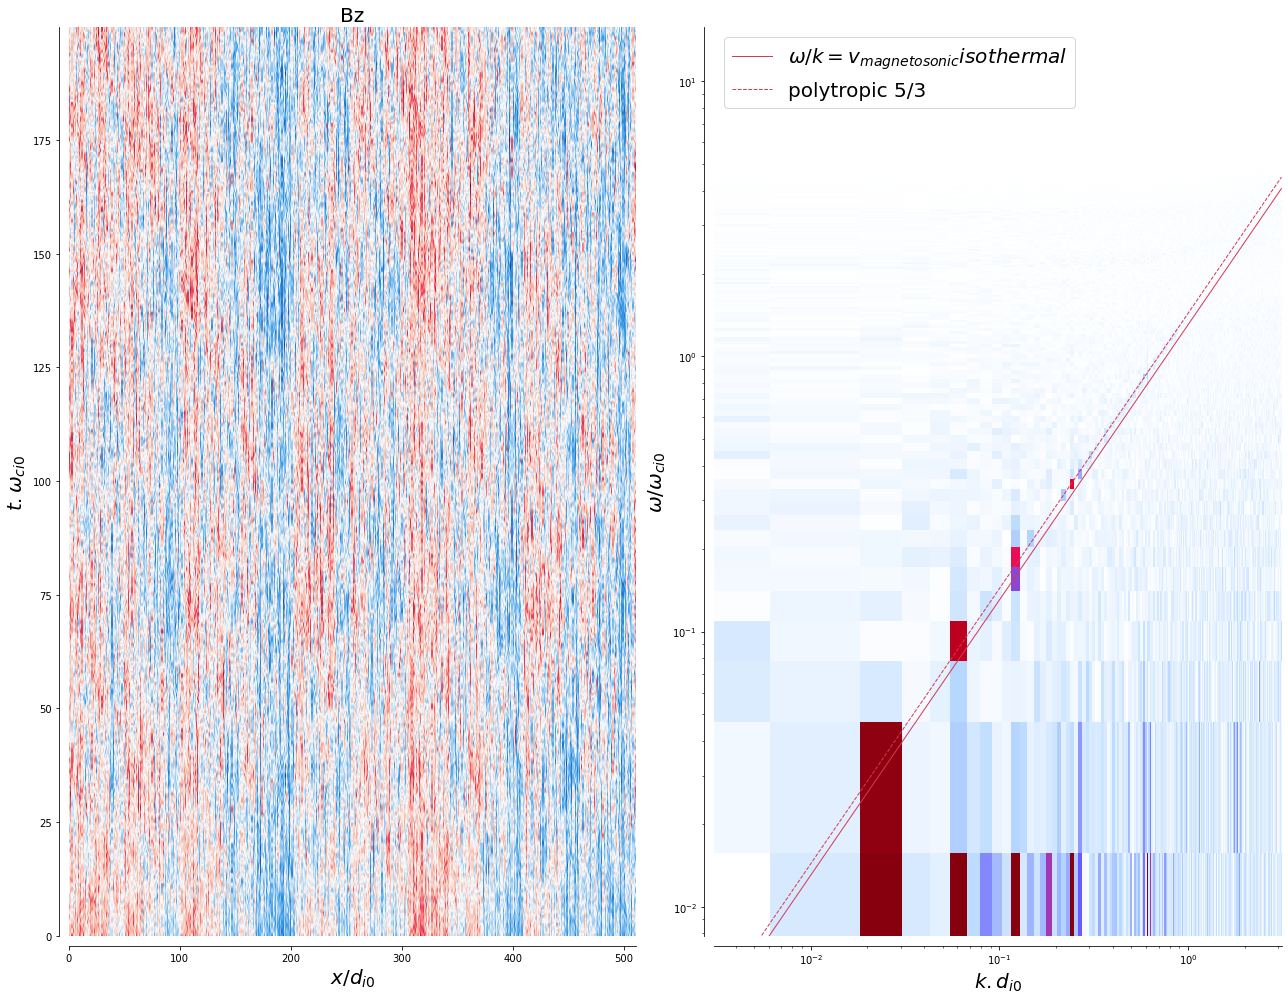

In [2]:
mp = menura_param(f'{path}')

#dens_t_s = np.load(f'{path}/products/dens_time_space.npy')
#E_t_s = np.load(f'{path}/products/E_time_space.npy')
B_t_s = np.load(f'{path}/products/B_time_space_rank0.npy')

#field_omega_k_spectrum(dens_t_s-np.mean(dens_t_s), 'Density', lp.dt_low, lp.dx_low, lp, disp_rel='magnetosonic')
#field_omega_k_spectrum(E_t_s[1]-np.mean(E_t_s[1]), 'Ey', lp.dt_low, lp.dx_low, lp, disp_rel='magnetosonic')
field_omega_k_spectrum(B_t_s[2]-np.mean(B_t_s[2]), 'Bz', mp.dt_low, mp.dx_low, mp, disp_rel='magnetosonic2', savefig=True)

The numerical dispersion relation follows nicely the magnetosonic dispersion relation for these "MHD-to-kinetic" scales. But why are a big portion of the initial modes' power not propagating in the magnetic field and density evolutions?